α = 0.2
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 0.792526, B = 3.020244
  Prefactor teórico de log(t): α(1-q)/q = 0.800000



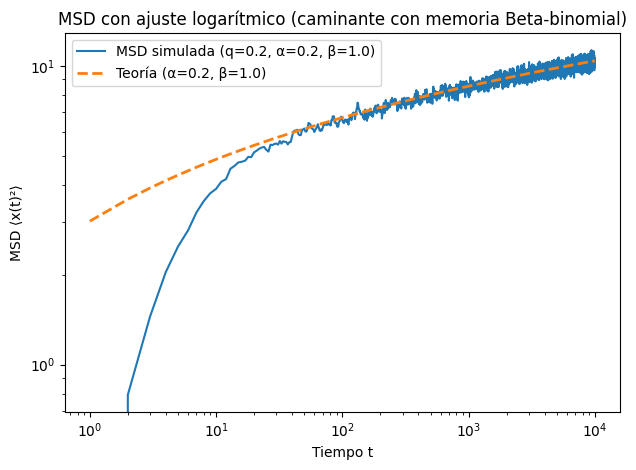

α = 0.5
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 2.007899, B = 0.791079
  Prefactor teórico de log(t): α(1-q)/q = 2.000000



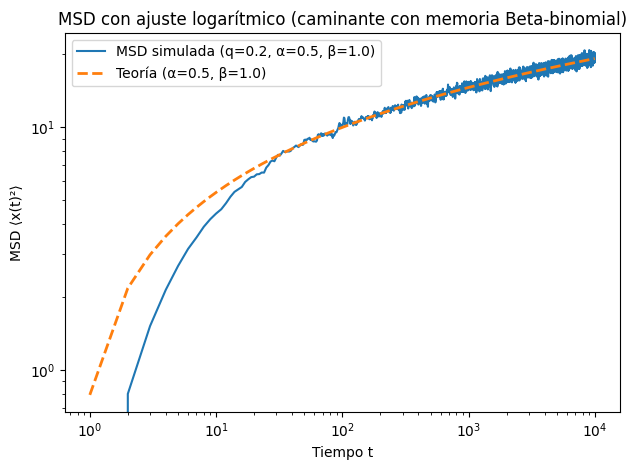

α = 1.2
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 4.807665, B = -6.107619
  Prefactor teórico de log(t): α(1-q)/q = 4.800000



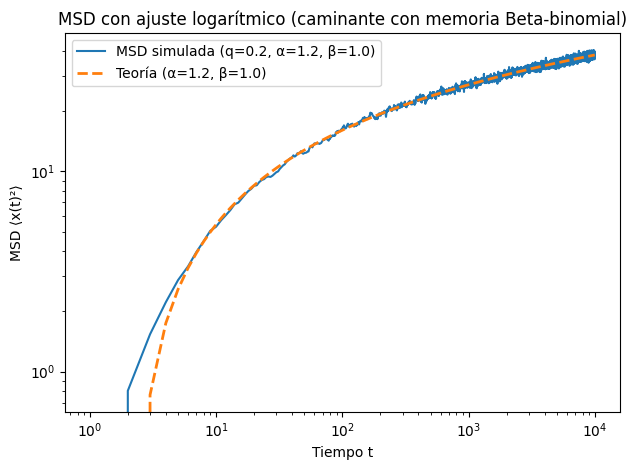

α = 1.5
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 5.979905, B = -9.578757
  Prefactor teórico de log(t): α(1-q)/q = 6.000000



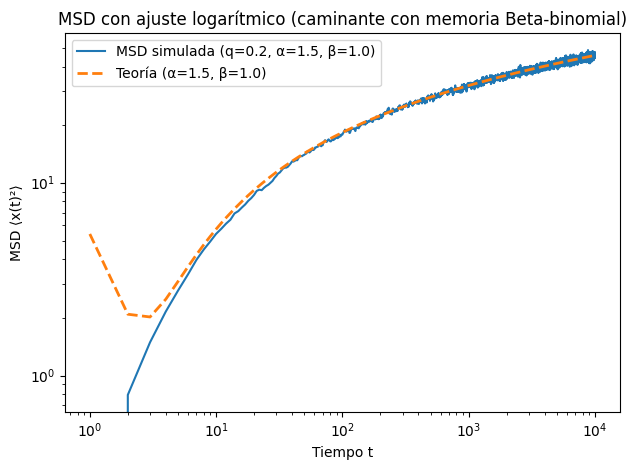

α = 1.7
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 6.771823, B = -11.834810
  Prefactor teórico de log(t): α(1-q)/q = 6.800000



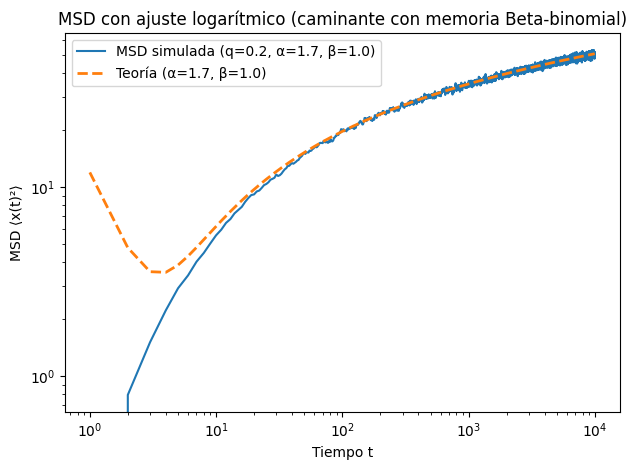

α = 2.0
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 0.860453, B = -0.699094
  Prefactor teórico de log(t): α(1-q)/q = 0.857143



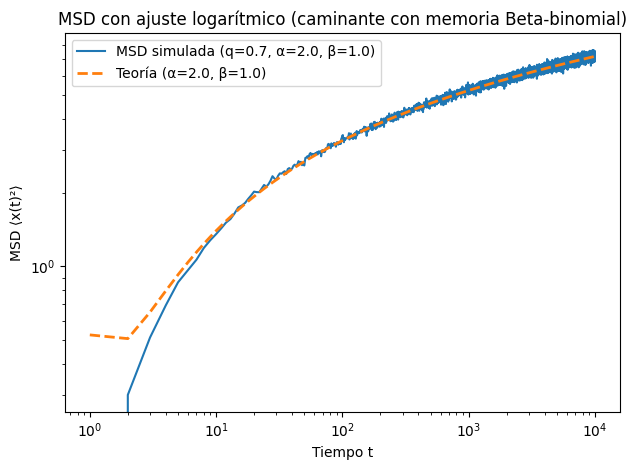

α = 3.0
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 11.937178, B = -30.002802
  Prefactor teórico de log(t): α(1-q)/q = 12.000000



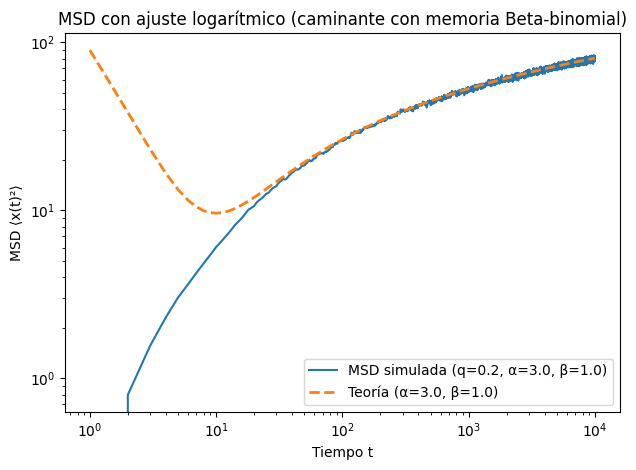

In [2]:
import numpy as np
import matplotlib.pyplot as plt

if __name__ == "__main__":
    # Ejemplo de uso: caso especial alpha=2, beta=1
    T = 10000
    n_traj = 5000
    q = 0.2
    alpha = 1.0
    beta = 1.0
    p = 0.5

    # Tiempo mínimo a partir del cual hacemos el ajuste (ajústalo a tu gusto)
    # Por ejemplo, a partir de t = 100
    t_fit_min = 100

    for alpha in [0.2,0.5,1.2, 1.5, 1.7, 2.0, 3.0]:
        if alpha == 2.0:
            q = 0.7
            msd = np.load(f"betha_1/msd_beta_binomial_{str(alpha)[0]}_{str(alpha)[-1]}_7.npy")
        else:
            q = 0.2
            msd = np.load(f"betha_1/msd_beta_binomial_{str(alpha)[0]}_{str(alpha)[-1]}.npy")

        # t desde 1 hasta len(msd), para evitar log(0)
        t = np.arange(1, len(msd) + 1, dtype=float)
        t_= np.arange(1, len(msd) + 1, dtype=float) 

        # ---------
        # Ajuste logarítmico MSD(t) ~ A log(t) + B
        # ---------
        mask = t >= t_fit_min
        x = np.log(t[mask])   # variable independiente: log t
        y = msd[mask]         # variable dependiente: MSD

        # polyfit grado 1: y ≈ A * x + B
        A, B = np.polyfit(x, y, 1)

        # MSD teórica:
        # para t grande, el término dominante es ~ (alpha*(1-q)/q) * log(q t)
        if alpha > 1:
            msd_theory = (
                np.log(t_) * alpha * (1 - q) / q
                + alpha * (alpha - 1) * (1 - q) / (t_ * q**2) + B
            )
        else:
            msd_theory = (np.log(t_) * alpha * (1 - q) / q + B)


        # MSD ajustada para todo el rango (y sirve para extrapolar)
        msd_logfit = A * np.log(t_) + B

        print(f"α = {alpha}")
        print(f"  Ajuste MSD(t) ≈ A log(t) + B con:")
        print(f"    A = {A:.6f}, B = {B:.6f}")
        print(f"  Prefactor teórico de log(t): α(1-q)/q = {alpha*(1-q)/q:.6f}\n")

        # ---------
        # Gráfica
        # ---------
        plt.figure()
        plt.plot(t, msd, label=f"MSD simulada (q={q}, α={alpha}, β={beta})")
        plt.plot(t_, msd_theory, lw=2, ls="--",
                 label=f"Teoría (α={alpha}, β={beta})")
        # plt.plot(t_, msd_logfit, lw=2, ls=":",
        #          label=f"Ajuste A log(t)+B (A={A:.3f})")

        # Para ver bien un crecimiento logarítmico, suele ser mejor:
        #   eje x logarítmico, eje y lineal
        plt.xscale("log")  # sólo log en el eje x
        plt.yscale("log")  # NO la activamos para que se vea el log(t) como curva
        plt.xlabel("Tiempo t")
        plt.ylabel("MSD ⟨x(t)²⟩")
        plt.title("MSD con ajuste logarítmico (caminante con memoria Beta-binomial)")
        plt.legend()
        plt.tight_layout()
        plt.show()
